In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math


## R = 218 kOhms - Klara 

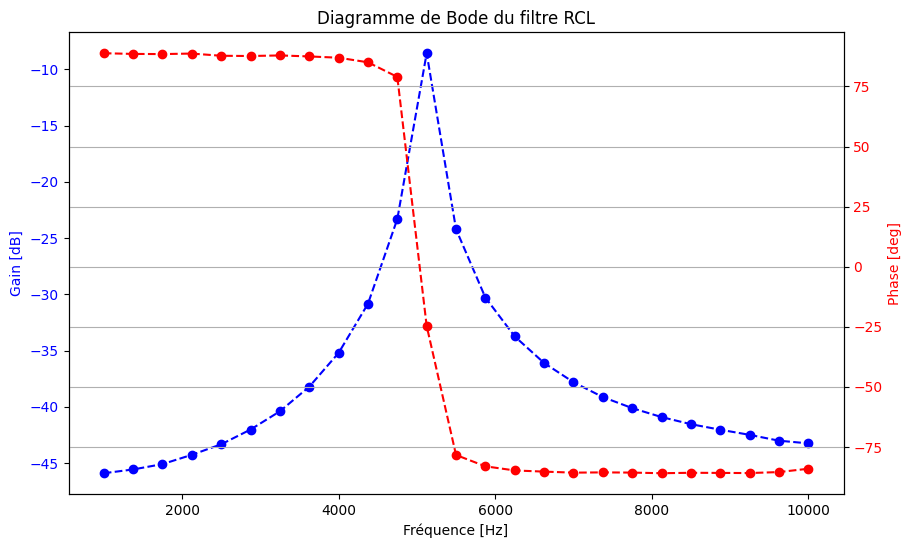

In [71]:
freq = pd.read_csv('Bode_278.csv')['Frequency [Hz]']
gain = pd.read_csv('Bode_278.csv')[' Amplitude [dB]']
phase = pd.read_csv('Bode_278.csv')[' Phase [deg]']


amp = 10**(gain/20)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot California sales
plt.plot(freq, gain, marker ='o', linestyle ='--', color ='b', label ='Gain')
ax1.set_xlabel('Fréquence [Hz]')
ax1.set_ylabel('Gain [dB]', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second Y-axis sharing the same X-axis
ax2 = ax1.twinx()

# Plot Texas sales
plt.plot(freq, phase, marker ='o', linestyle = '--', color ='r', label ='phase')
ax2.set_ylabel('Phase [deg]', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Add title and legend
plt.title("Diagramme de Bode du filtre RCL")
plt.grid(which='both')
plt.show()

<>:120: SyntaxWarning: invalid escape sequence '\o'
<>:121: SyntaxWarning: invalid escape sequence '\o'
<>:120: SyntaxWarning: invalid escape sequence '\o'
<>:121: SyntaxWarning: invalid escape sequence '\o'
C:\Users\klara\AppData\Local\Temp\ipykernel_9588\4097249337.py:120: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$H( \omega )$')
C:\Users\klara\AppData\Local\Temp\ipykernel_9588\4097249337.py:121: SyntaxWarning: invalid escape sequence '\o'
  plt.title('Amplitude de la fonction de transfert $H(\omega)$ en fonction de la fréquence')


[5.08747708e+03 4.62050497e-01 4.97376963e+01] [6.18134264 0.04173937 4.73822965]
params model2: 5106.4175547 32084.567752014955 0.59 218000
model2 Q 41.26717104264163
####################################
Fit - Q determine a l'oeil
Q: 57
fréquence de résonance: 5106.4175547
Rp: 313707.31707317074
R: 218000
pertes: 0.59
####################################
Q_int attendu:  100.65163668936985
Q_ext attendu:  69.9443576993926
Q attendu: 41.26717104264163
f0 attendu : 5032.921210448703
Q int obtenu 307.99739017197106


Text(0.5, 1.0, 'Amplitude de la fonction de transfert $H(\\omega)$ en fonction de la fréquence')

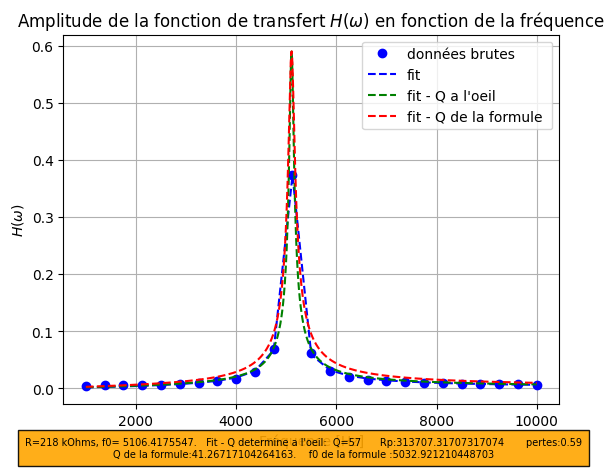

In [352]:

freq = pd.read_csv('Bode_278.csv')['Frequency [Hz]']
gain = pd.read_csv('Bode_278.csv')[' Amplitude [dB]']
phase = pd.read_csv('Bode_278.csv')[' Phase [deg]']


amp = 10**(gain/20)
amp218 = 10**(gain/20)

def model(w, w0, A, Q):                                    
    return A/np.sqrt((1+Q**2*(w/w0 - w0/w)**2))

def Qint(Q, R, f0, C=C):
    omega0 = 2*np.pi*f0
    Q_ext = R * C * omega0
    return 1/ (1/Q - 1/Q_ext)

def Rp(R,A):
    return A*R/(1-A)

def Q_int_dir(rp,w0, C=10*1E-9):
    Q_int = rp*C*w0
    #print("Q in Q int params ",rp, w0, C)
    #print("Q in Q int", 1/(rp*C*w0))
    return Q_int

def Q_ext_dir(R,w0, C=10*1E-9):
    Q_ext = R*C*w0
    #print("Q in Q est params ",R, w0, C)
    #print("Q in Q ext", 1/(R*C*w0))
    return Q_ext

def model2(f, f0, A, R): 
    w0=f0*np.pi*2
    print("params model2:",f0,w0, A, R)
    """Q= ((1/R+1/Rp(R,A))*1/(w0*10*1E-9))**(-1)  
    print("Q model 2:", Q)  
    Q= (1/(R*w0*10*1E-9)+1/(Rp(R,A)*w0*10*1E-9))**(-1)  
    print("Q model 2:", Q)  
    Q= ((Rp(R,A)+ R )/(Rp(R,A)*R*w0*10*1E-9))**(-1)  
    print("Q model 2:", Q) 
    print( 1/(Rp(R,A)*w0*10*1E-9), 1/ Q_int_dir(Rp(R,A),w0, C=10*1E-9),1/(R*w0*10*1E-9), 1/ Q_ext_dir(R,w0, C=10*1E-9))
    print(  Q_int_dir(Rp(R,A),w0, C=10*1E-9),  Q_ext_dir(R,w0, C=10*1E-9))
    print(Rp(R,A)) """ 
    #print(R,A)
    #print(Rp(R,A))
    #print( 1/(Rp(R,A)*w0*10*1E-9), 1/ Q_int_dir(Rp(R,A),w0, C=10*1E-9),1/(R*w0*10*1E-9), 1/ Q_ext_dir(R,w0, C=10*1E-9))
    Q= (1/Q_int_dir(Rp(R,A),w0, C=10*1E-9)+1/Q_ext_dir(R, w0, C=10*1E-9))**(-1) 

    print("model2 Q", Q) 
    #print("Q model 2:", Q)                        
    return A/np.sqrt((1+Q**2*(f/f0 - f0/f)**2)) #+0.01




    
freq_np = freq.to_numpy()
amp_np = amp.to_numpy()
amp_np218=amp_np
freq_np218=freq_np



omega0, A, Q = popt
omega0 = omega0*2*np.pi

plt.plot(freq_np, amp_np, 'o', label ='données brutes', color ='b')

#plt.plot(freq_np, model(freq_np, *p0), label = "à l'oeil")

###  curve fit 
p0 = (5106.4175547, 0.59, 57)
popt, pcov = curve_fit(model, freq_np, amp_np, p0)
plt.plot(freq_np, model(freq_np, *popt), label = "fit", linestyle ='--', color ='b')
perr = np.sqrt(np.diag(pcov))
print(popt, perr)

####
freq_np = np.linspace(np.min(freq_np), np.max(freq_np), 1000)
#print("Aa",popt)
plt.plot(freq_np, model(freq_np, 5106.4175547, 0.59, 57), label = "fit - Q a l'oeil", linestyle ='--', color ='g')
plt.plot(freq_np, model2(freq_np, 5106.4175547, 0.59, 218000), label = "fit - Q de la formule ", linestyle ='--', color ='r')
#model2(w, w0, A, R)
#5136.4175547     7.4421871  -163.11667159

plt.legend()
f0, A, R, Q = 5106.4175547, 0.59, 218000, 57
w0=f0*np.pi*2

#Q= (1/Q_int_dir(Rp(R,A),w0, C=10*1E-9)+1/Q_ext_dir(R, w0, C=10*1E-9))**(-1) 

#print(R,10E+0)
rp=Rp(R,A)
#print(rp)
print("####################################")
print("Fit - Q determine a l'oeil")
print("Q:",Q)
print('fréquence de résonance:', f0)
print('Rp:', rp)
print("R:",R)
print("pertes:", rp/(rp+R))
#print('Rp', Rp_bis(abs(Q_int(Q, R,omega0)), omega0 ))
print("####################################")
#print(rp,w0)
print('Q_int attendu: ', Q_int_dir(rp,w0))
print('Q_ext attendu: ', Q_ext_dir(R,w0))
print("Q attendu:", (1/Q_int_dir(rp,w0)+1/Q_ext_dir(R,w0))**(-1))
print('f0 attendu :', 1/(0.1*10*1E-9)**(1/2)/np.pi/2)
"""print('Valeur attendue de Quint', R*10*1E-9*omega0 )
print('Valeur attendue de Quint', R*10*1E-9*omega0 )"""
mask = model(freq_np, *popt) == np.max(model(freq_np, *popt))
print("Q int obtenu",Qint(Q, R, f0, C=C))
#print(freq_np[mask])
#print(len(amp_np))
plt.figtext(0.5, 0, "R=218 kOhms, f0= "+str(f0)+".   Fit - Q determine a l'oeil:  Q="+str(Q)+'      Rp:'+ str(rp) + "       pertes:"+ str(rp/(rp+R))+
            "\nQ de la formule:"+str((1/Q_int_dir(rp,w0)+1/Q_ext_dir(R,w0))**(-1))+ '.    f0 de la formule :'+ str(1/(0.1*10*1E-9)**(1/2)/np.pi/2), ha="center", fontsize=7, bbox={"facecolor":"orange", "alpha":0.9, "pad":5})

plt.grid()
plt.xlabel('Fréquence [Hz]')
plt.ylabel('$H( \omega )$')
plt.title('Amplitude de la fonction de transfert $H(\omega)$ en fonction de la fréquence')


## R 100 kOhms - Klara

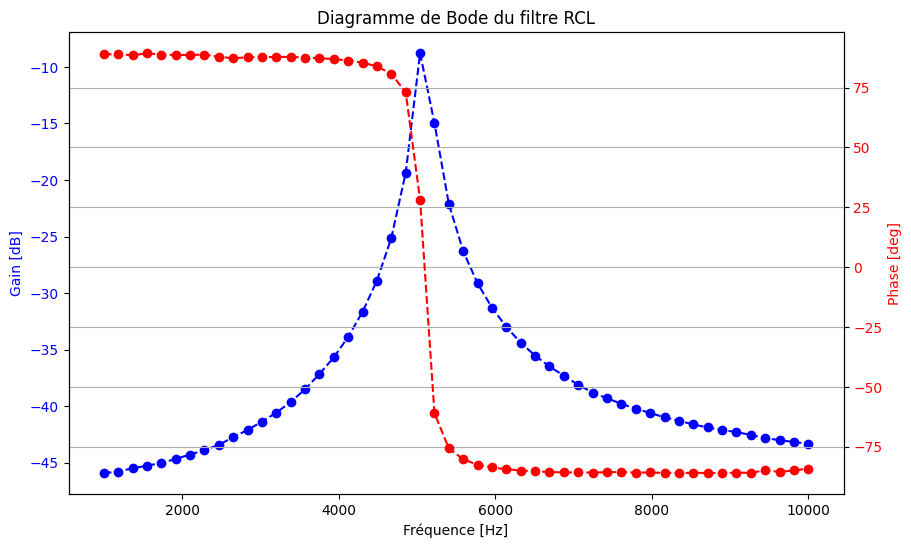

In [297]:

freq = pd.read_csv('Bode_100.csv')['Frequency [Hz]']
gain = pd.read_csv('Bode_100.csv')[' Amplitude [dB]']
phase = pd.read_csv('Bode_100.csv')[' Phase [deg]']


amp = 10**(gain/20)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot California sales
plt.plot(freq, gain, marker ='o', linestyle ='--', color ='b', label ='Gain')
ax1.set_xlabel('Fréquence [Hz]')
ax1.set_ylabel('Gain [dB]', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second Y-axis sharing the same X-axis
ax2 = ax1.twinx()

# Plot Texas sales
plt.plot(freq, phase, marker ='o', linestyle = '--', color ='r', label ='phase')
ax2.set_ylabel('Phase [deg]', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Add title and legend
plt.title("Diagramme de Bode du filtre RCL")
plt.grid(which='both')
plt.show()

params model2: 5106.4175547 32084.567752014955 0.47 100000
model2 Q 15.079746843447031
####################################
Fit - Q determine a l'oeil
Q: 41
fréquence de résonance: 5106.4175547
Rp: 100000.0
R: 100000
pertes: 0.5
####################################
Q_int attendu:  32.084567752014955
Q_ext attendu:  32.084567752014955
Q attendu: 16.042283876007478
f0 attendu : 5032.921210448703


<>:106: SyntaxWarning: invalid escape sequence '\o'
<>:107: SyntaxWarning: invalid escape sequence '\o'
<>:106: SyntaxWarning: invalid escape sequence '\o'
<>:107: SyntaxWarning: invalid escape sequence '\o'
C:\Users\klara\AppData\Local\Temp\ipykernel_9588\2733145156.py:106: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$H( \omega )$')
C:\Users\klara\AppData\Local\Temp\ipykernel_9588\2733145156.py:107: SyntaxWarning: invalid escape sequence '\o'
  plt.title('Amplitude de la fonction de transfert $H(\omega)$ en fonction de la fréquence')


Text(0.5, 1.0, 'Amplitude de la fonction de transfert $H(\\omega)$ en fonction de la fréquence')

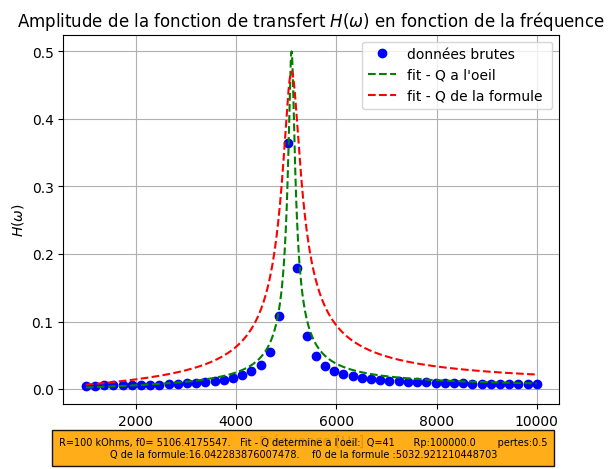

In [ ]:

freq = pd.read_csv('Bode_100.csv')['Frequency [Hz]']
gain = pd.read_csv('Bode_100.csv')[' Amplitude [dB]']
phase = pd.read_csv('Bode_100.csv')[' Phase [deg]']


amp = 10**(gain/20)


def model(w, w0, A, Q):                                    
    return A/np.sqrt((1+Q**2*(w/w0 - w0/w)**2))

def Rp(R,A):
    return A*R/(1-A)

def Q_int_dir(rp,w0, C=10*1E-9):
    Q_int = rp*C*w0
    #print("Q in Q int params ",rp, w0, C)
    #print("Q in Q int", 1/(rp*C*w0))
    return Q_int

def Q_ext_dir(R,w0, C=10*1E-9):
    Q_ext = R*C*w0
    #print("Q in Q est params ",R, w0, C)
    #print("Q in Q ext", 1/(R*C*w0))
    return Q_ext

def model2(f, f0, A, R): 
    w0=f0*np.pi*2
    print("params model2:",f0,w0, A, R)
    """Q= ((1/R+1/Rp(R,A))*1/(w0*10*1E-9))**(-1)  
    print("Q model 2:", Q)  
    Q= (1/(R*w0*10*1E-9)+1/(Rp(R,A)*w0*10*1E-9))**(-1)  
    print("Q model 2:", Q)  
    Q= ((Rp(R,A)+ R )/(Rp(R,A)*R*w0*10*1E-9))**(-1)  
    print("Q model 2:", Q) 
    print( 1/(Rp(R,A)*w0*10*1E-9), 1/ Q_int_dir(Rp(R,A),w0, C=10*1E-9),1/(R*w0*10*1E-9), 1/ Q_ext_dir(R,w0, C=10*1E-9))
    print(  Q_int_dir(Rp(R,A),w0, C=10*1E-9),  Q_ext_dir(R,w0, C=10*1E-9))
    print(Rp(R,A)) """ 
    #print(R,A)
    #print(Rp(R,A))
    #print( 1/(Rp(R,A)*w0*10*1E-9), 1/ Q_int_dir(Rp(R,A),w0, C=10*1E-9),1/(R*w0*10*1E-9), 1/ Q_ext_dir(R,w0, C=10*1E-9))
    Q= (1/Q_int_dir(Rp(R,A),w0, C=10*1E-9)+1/Q_ext_dir(R, w0, C=10*1E-9))**(-1) 

    print("model2 Q", Q) 
    #print("Q model 2:", Q)                        
    return A/np.sqrt((1+Q**2*(f/f0 - f0/f)**2)) #+0.01




    
freq_np = freq.to_numpy()
amp_np = amp.to_numpy()
amp_np100=amp_np
freq_np100=freq_np

p0 = (5136.4175547, 1, 19)

popt, pcov = curve_fit(model, freq_np, amp_np, p0)
omega0, A, Q = popt
omega0 = omega0*2*np.pi

plt.plot(freq_np, amp_np, 'o', label ='données brutes', color ='b')
freq_np = np.linspace(np.min(freq_np), np.max(freq_np), 1000)
#plt.plot(freq_np, model(freq_np, *p0), label = "à l'oeil")
#plt.plot(freq_np, model(freq_np, *popt), label = "fit", linestyle ='--', color ='r')
#print("Aa",popt)
plt.plot(freq_np, model(freq_np, 5106.4175547, 0.50, 41), label = "fit - Q a l'oeil", linestyle ='--', color ='g')
plt.plot(freq_np, model2(freq_np, 5106.4175547, 0.47, 100000), label = "fit - Q de la formule ", linestyle ='--', color ='r')
#model2(w, w0, A, R)
#5136.4175547     7.4421871  -163.11667159

plt.legend()
f0, A, R, Q = 5106.4175547, 0.50, 100000, 41
w0=f0*np.pi*2

#Q= (1/Q_int_dir(Rp(R,A),w0, C=10*1E-9)+1/Q_ext_dir(R, w0, C=10*1E-9))**(-1) 

#print(R,10E+0)
rp=Rp(R,A)
#print(rp)
print("####################################")
print("Fit - Q determine a l'oeil")
print("Q:",Q)
print('fréquence de résonance:', f0)
print('Rp:', rp)
print("R:",R)
print("pertes:", rp/(rp+R))
#print('Rp', Rp_bis(abs(Q_int(Q, R,omega0)), omega0 ))
print("####################################")
#print(rp,w0)
print('Q_int attendu: ', Q_int_dir(rp,w0))
print('Q_ext attendu: ', Q_ext_dir(R,w0))
print("Q attendu:", (1/Q_int_dir(rp,w0)+1/Q_ext_dir(R,w0))**(-1))
print('f0 attendu :', 1/(0.1*10*1E-9)**(1/2)/np.pi/2)
print("Q int obtenu",Qint(Q, R, f0, C=C))
"""print('Valeur attendue de Quint', R*10*1E-9*omega0 )
print('Valeur attendue de Quint', R*10*1E-9*omega0 )"""
mask = model(freq_np, *popt) == np.max(model(freq_np, *popt))
#print(freq_np[mask])
#print(len(amp_np))
plt.figtext(0.5, 0, "R=100 kOhms, f0= "+str(f0)+".   Fit - Q determine a l'oeil:  Q="+str(Q)+'      Rp:'+ str(rp) + "       pertes:"+ str(rp/(rp+R))+
            "\nQ de la formule:"+str((1/Q_int_dir(rp,w0)+1/Q_ext_dir(R,w0))**(-1))+ '.    f0 de la formule :'+ str(1/(0.1*10*1E-9)**(1/2)/np.pi/2), ha="center", fontsize=7, bbox={"facecolor":"orange", "alpha":0.9, "pad":5})

plt.grid()
plt.xlabel('Fréquence [Hz]')
plt.ylabel('$H( \omega )$')
plt.title('Amplitude de la fonction de transfert $H(\omega)$ en fonction de la fréquence')


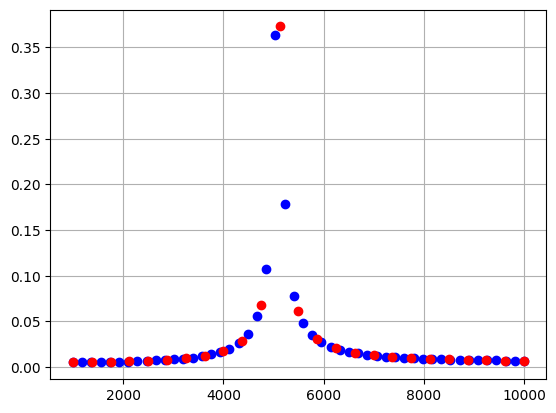

In [300]:
plt.plot(freq_np100, amp_np100, 'o', label ='données brutes', color ='b')
plt.plot(freq_np218, amp_np218, 'o', label ='données brutes', color ='r')
plt.grid()
plt.show()


## R = 47 kOhm - Klara

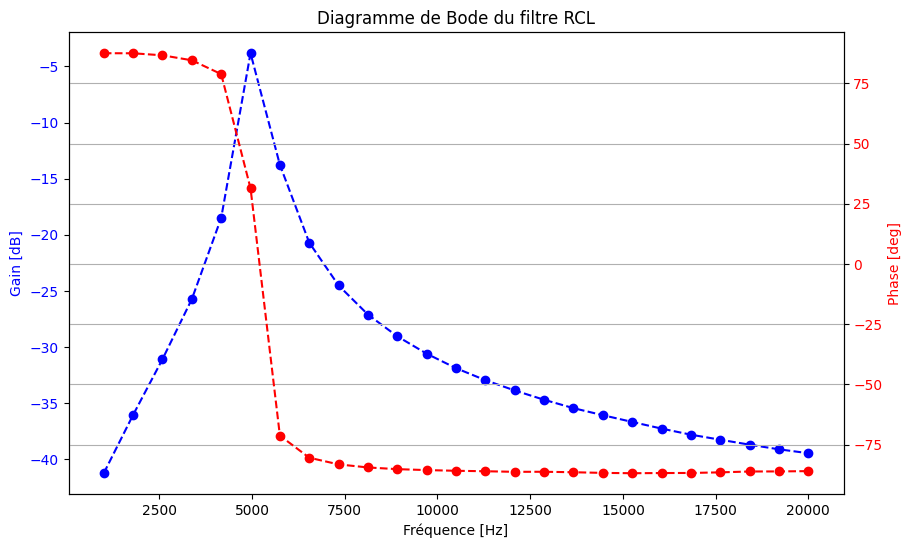

In [228]:

freq = pd.read_csv('Bode_47.csv')['Frequency [Hz]']
gain = pd.read_csv('Bode_47.csv')[' Amplitude [dB]']
phase = pd.read_csv('Bode_47.csv')[' Phase [deg]']


amp = 10**(gain/20)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot California sales
plt.plot(freq, gain, marker ='o', linestyle ='--', color ='b', label ='Gain')
ax1.set_xlabel('Fréquence [Hz]')
ax1.set_ylabel('Gain [dB]', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second Y-axis sharing the same X-axis
ax2 = ax1.twinx()

# Plot Texas sales
plt.plot(freq, phase, marker ='o', linestyle = '--', color ='r', label ='phase')
ax2.set_ylabel('Phase [deg]', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Add title and legend
plt.title("Diagramme de Bode du filtre RCL")
plt.grid(which='both')
plt.show()

<>:127: SyntaxWarning: invalid escape sequence '\o'
<>:128: SyntaxWarning: invalid escape sequence '\o'
<>:127: SyntaxWarning: invalid escape sequence '\o'
<>:128: SyntaxWarning: invalid escape sequence '\o'
C:\Users\klara\AppData\Local\Temp\ipykernel_9588\1886281357.py:127: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$H( \omega )$')
C:\Users\klara\AppData\Local\Temp\ipykernel_9588\1886281357.py:128: SyntaxWarning: invalid escape sequence '\o'
  plt.title('Amplitude de la fonction de transfert $H(\omega)$ en fonction de la fréquence')


[5136.41751507    7.4418906   163.11015942] [  10.66532069   72.54104106 1592.47899203]
params model2: 5106.4175547 32084.567752014955 0.88 47000
model2 Q 13.270177222233386
####################################
Fit - Q determine a l'oeil
Q: 18
fréquence de résonance: 5106.4175547
Rp: 344666.6666666667
R: 47000
pertes: 0.88
####################################
Q_int attendu:  110.58481018527822
Q_ext attendu:  15.079746843447028
13.270177222233386
Q attendu: 13.270177222233386
f0 attendu : 5032.921210448703
0.05555555555555555 0.06631411060024224
Q int obtenu -92.94928508953147


Text(0.5, 1.0, 'Amplitude de la fonction de transfert $H(\\omega)$ en fonction de la fréquence')

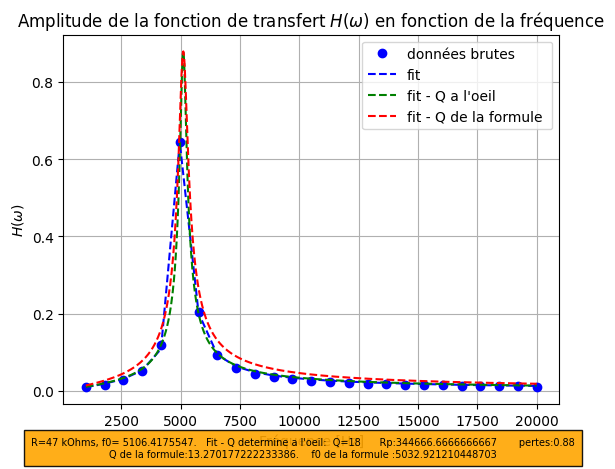

In [353]:

freq = pd.read_csv('Bode_47.csv')['Frequency [Hz]']
gain = pd.read_csv('Bode_47.csv')[' Amplitude [dB]']
phase = pd.read_csv('Bode_47.csv')[' Phase [deg]']


amp = 10**(gain/20)


def model(w, w0, A, Q):                                    
    return A/np.sqrt((1+Q**2*(w/w0 - w0/w)**2))

def Rp(R,A):
    return A*R/(1-A)

def Q_int_dir(rp,w0, C=10*1E-9):
    Q_int = rp*C*w0
    #print("Q in Q int params ",rp, w0, C)
    #print("Q in Q int", 1/(rp*C*w0))
    return Q_int

def Q_ext_dir(R,w0, C=10*1E-9):
    Q_ext = R*C*w0
    #print("Q in Q est params ",R, w0, C)
    #print("Q in Q ext", 1/(R*C*w0))
    return Q_ext

def Qint(Q, R, f0, C=C):
    omega0 = 2*np.pi*f0
    Q_ext = R * C * omega0
    print(1/Q, 1/Q_ext)
    return 1/ (1/Q - 1/Q_ext)

def model2(f, f0, A, R): 
    w0=f0*np.pi*2
    print("params model2:",f0,w0, A, R)
    """Q= ((1/R+1/Rp(R,A))*1/(w0*10*1E-9))**(-1)  
    print("Q model 2:", Q)  
    Q= (1/(R*w0*10*1E-9)+1/(Rp(R,A)*w0*10*1E-9))**(-1)  
    print("Q model 2:", Q)  
    Q= ((Rp(R,A)+ R )/(Rp(R,A)*R*w0*10*1E-9))**(-1)  
    print("Q model 2:", Q) 
    print( 1/(Rp(R,A)*w0*10*1E-9), 1/ Q_int_dir(Rp(R,A),w0, C=10*1E-9),1/(R*w0*10*1E-9), 1/ Q_ext_dir(R,w0, C=10*1E-9))
    print(  Q_int_dir(Rp(R,A),w0, C=10*1E-9),  Q_ext_dir(R,w0, C=10*1E-9))
    print(Rp(R,A)) """ 
    #print(R,A)
    #print(Rp(R,A))
    #print( 1/(Rp(R,A)*w0*10*1E-9), 1/ Q_int_dir(Rp(R,A),w0, C=10*1E-9),1/(R*w0*10*1E-9), 1/ Q_ext_dir(R,w0, C=10*1E-9))
    Q= (1/Q_int_dir(Rp(R,A),w0, C=10*1E-9)+1/Q_ext_dir(R, w0, C=10*1E-9))**(-1) 

    print("model2 Q", Q) 
    #print("Q model 2:", Q)                        
    return A/np.sqrt((1+Q**2*(f/f0 - f0/f)**2)) #+0.01




    
freq_np = freq.to_numpy()
amp_np = amp.to_numpy()
freq_np47=freq_np
amp_np47=amp_np


p0 = (5136.4175547, 1, 19)

popt, pcov = curve_fit(model, freq_np, amp_np, p0)
omega0, A, Q = popt
omega0 = omega0*2*np.pi

plt.plot(freq_np, amp_np, 'o', label ='données brutes', color ='b')



###  curve fit 
p0 = (5106.4175547, 0.59, 57)
popt, pcov = curve_fit(model, freq_np, amp_np, p0)
plt.plot(freq_np, model(freq_np, *popt), label = "fit", linestyle ='--', color ='b')
perr = np.sqrt(np.diag(pcov))
print(popt, perr)

freq_np = np.linspace(np.min(freq_np), np.max(freq_np), 1000)
#plt.plot(freq_np, model(freq_np, *p0), label = "à l'oeil")
#plt.plot(freq_np, model(freq_np, *popt), label = "fit", linestyle ='--', color ='r')


#print("Aa",popt)
plt.plot(freq_np, model(freq_np, 5106.4175547, 0.88, 18), label = "fit - Q a l'oeil", linestyle ='--', color ='g')
plt.plot(freq_np, model2(freq_np, 5106.4175547, 0.88, 47000), label = "fit - Q de la formule ", linestyle ='--', color ='r')
#model2(w, w0, A, R)
#5136.4175547     7.4421871  -163.11667159

plt.legend()
f0, A, R, Q = 5106.4175547, 0.88, 47000, 18
w0=f0*np.pi*2

#Q= (1/Q_int_dir(Rp(R,A),w0, C=10*1E-9)+1/Q_ext_dir(R, w0, C=10*1E-9))**(-1) 

#print(R,10E+0)
rp=Rp(R,A)
#print(rp)
print("####################################")
print("Fit - Q determine a l'oeil")
print("Q:",Q)
print('fréquence de résonance:', f0)
print('Rp:', rp)
print("R:",R)
print("pertes:", rp/(rp+R))
#print('Rp', Rp_bis(abs(Q_int(Q, R,omega0)), omega0 ))
print("####################################")
#print(rp,w0)
print('Q_int attendu: ', Q_int_dir(rp,w0))
print('Q_ext attendu: ', Q_ext_dir(R,w0))
print(1/(1/Q_int_dir(rp,w0)+1/Q_ext_dir(R,w0)))
print("Q attendu:", (1/Q_int_dir(rp,w0)+1/Q_ext_dir(R,w0))**(-1))
print('f0 attendu :', 1/(0.1*10*1E-9)**(1/2)/np.pi/2)
print("Q int obtenu",Qint(Q, R, f0, C=C))
"""print('Valeur attendue de Quint', R*10*1E-9*omega0 )
print('Valeur attendue de Quint', R*10*1E-9*omega0 )"""
mask = model(freq_np, *popt) == np.max(model(freq_np, *popt))
#print(freq_np[mask])
#print(len(amp_np))

plt.figtext(0.5, 0, "R=47 kOhms, f0= "+str(f0)+".   Fit - Q determine a l'oeil:  Q="+str(Q)+'      Rp:'+ str(rp) + "       pertes:"+ str(rp/(rp+R))+
            "\nQ de la formule:"+str((1/Q_int_dir(rp,w0)+1/Q_ext_dir(R,w0))**(-1))+ '.    f0 de la formule :'+ str(1/(0.1*10*1E-9)**(1/2)/np.pi/2), ha="center", fontsize=7, bbox={"facecolor":"orange", "alpha":0.9, "pad":5})
plt.grid()
plt.xlabel('Fréquence [Hz]')
plt.ylabel('$H( \omega )$')
plt.title('Amplitude de la fonction de transfert $H(\omega)$ en fonction de la fréquence')


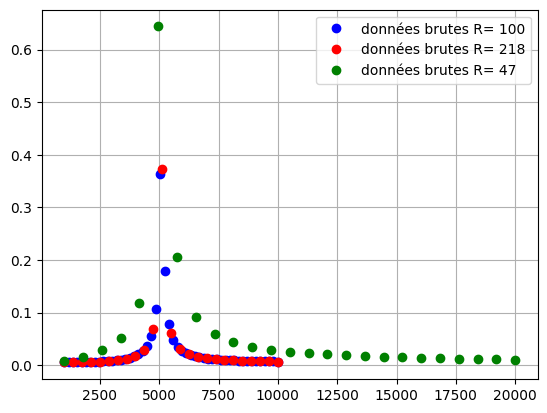

In [303]:
plt.plot(freq_np100, amp_np100, 'o', label ='données brutes R= 100', color ='b')
plt.plot(freq_np218, amp_np218, 'o', label ='données brutes R= 218', color ='r')
plt.plot(freq_np47, amp_np47, 'o', label ='données brutes R= 47', color ='g')
plt.legend()
plt.grid()
plt.show()

## R = 100 kOhm (bis)


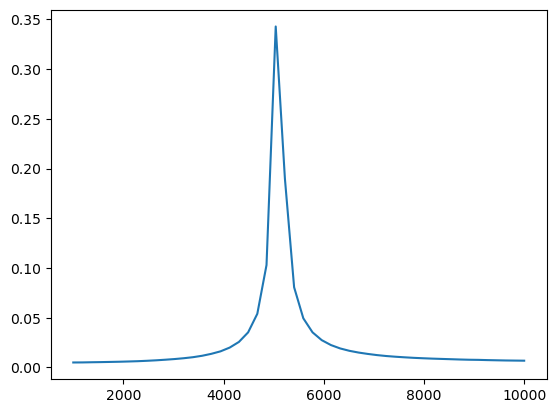

In [ ]:
freq = pd.read_csv('Bode_100_bis.csv')['Frequency [Hz]']
gain = pd.read_csv('Bode_100_bis.csv')[' Amplitude [dB]']

amp = 10**(gain/20)
plt.plot(freq, amp)
plt.show()

fréquence de résonance 32046.566672104243
facteur de qualité 69.02575728678396
Rp 88736.46397023537
Rp 38581.299852289994
Q_int 12.36398198012857
Valeur attendue de Quint 15.061886335888996
[5099.0990991]
50


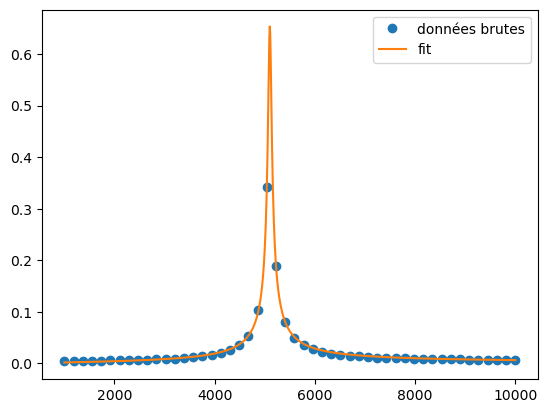

In [ ]:

def model(w, w0, A, Q):                                    
    return A/np.sqrt((1+Q**2*(w/w0 - w0/w)**2))
    
freq_np = freq.to_numpy()
amp_np = amp.to_numpy()


p0 = (5000, 0.6, 1000)

popt, pcov = curve_fit(model, freq_np, amp_np, p0)
omega0, A, Q = popt
omega0 = omega0*2*np.pi

plt.plot(freq_np, amp_np, 'o', label ='données brutes')
freq_np = np.linspace(np.min(freq_np), np.max(freq_np), 1000)
#plt.plot(freq_np, model(freq_np, *p0), label = "à l'oeil")
plt.plot(freq_np, model(freq_np, *popt), label = "fit")
plt.legend()

print('fréquence de résonance', omega0)
print('facteur de qualité', abs(Q))
print('Rp', Rp(R,A))
print('Rp', Rp_bis(abs(Q_int(Q, R,omega0)), omega0 ))
print('Q_int', abs(Q_int(Q, R,omega0)) )
print('Valeur attendue de Quint', R*10*1E-9*omega0 )
mask = model(freq_np, *popt) == np.max(model(freq_np, *popt))
print(freq_np[mask])
print(len(amp_np))


## R = 218 kOhm

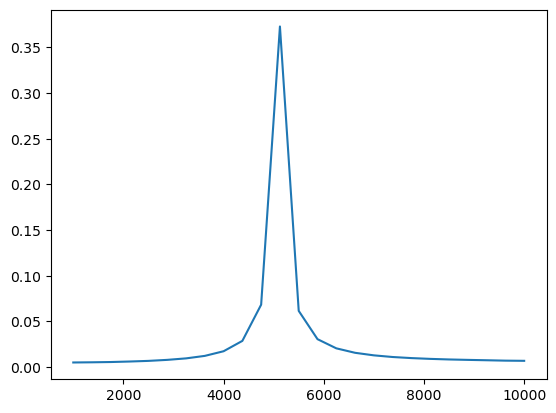

In [ ]:
freq = pd.read_csv('Bode_278.csv')['Frequency [Hz]']
gain = pd.read_csv('Bode_278.csv')[' Amplitude [dB]']

amp = 10**(gain/20)
plt.plot(freq, amp)
plt.show()

Pulsation de résonance 31965.560779347306
facteur de qualité 49.737752848032855
Rp 40368.87814852261
Rp 67341.08638276088
Q_int 21.5259558971542
Valeur attendue de Qext 15.023813566293235
[5090.09009009]


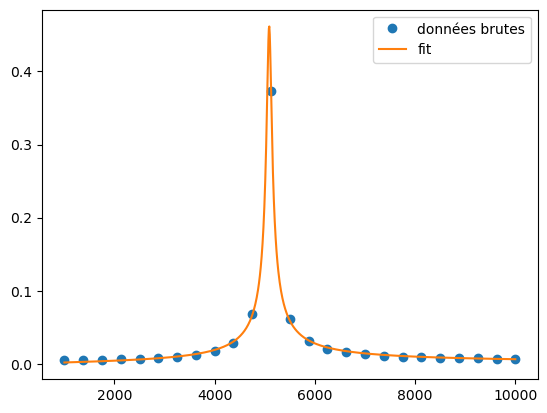

In [ ]:

def model(w, w0, A, Q):                                    
    return A/np.sqrt((1+Q**2*(w/w0 - w0/w)**2))
    
freq_np = freq.to_numpy()
amp_np = amp.to_numpy()


p0 = (5000, 0.6, 1000)

popt, pcov = curve_fit(model, freq_np, amp_np, p0)
omega0, A, Q = popt
omega0 = omega0*2*np.pi


plt.plot(freq_np, amp_np, 'o', label ='données brutes')
freq_np = np.linspace(np.min(freq_np), np.max(freq_np), 1000)
#plt.plot(freq_np, model(freq_np, *p0), label = "à l'oeil")
plt.plot(freq_np, model(freq_np, *popt), label = "fit")
plt.legend()

print('Pulsation de résonance', omega0)
print('facteur de qualité', abs(Q))
print('Rp', Rp(R,A))
print('Rp', Rp_bis(abs(Q_int(Q, R,omega0)), omega0 ))
print('Q_int', abs(Q_int(Q, R,omega0)) )
print('Valeur attendue de Qext', R*10*1E-9*omega0 )
mask = model(freq_np, *popt) == np.max(model(freq_np, *popt))
print(freq_np[mask])

# Partie 4 - Démarage des oscillations


Gain au démarrage des oscillations :

In [ ]:
R2 = 2E3
R1 = 1.8E3
G_dem = 1+R2/R1
print("Gain au démarrage des oscillations", 1 + R2/R1)

Gain au démarrage des oscillations 2.111111111111111


On a que $|H(\omega_0)| = \frac{R_p}{R+R_p}$.

Critère de Barkhausen : condition nécessaire pour qu'un circuit constitué d'un amplificateur et d'une boucle de contre-réaction se mette à osciller. La conditin sur l'amplitude dit que le gain de contre-réaction est de , c'est à dire $|H(\omega) G| = 1 = G |H(\omega)|$. Donc à la fréquence de résonance $\omega_0$, on a  $G \frac{R_p}{R+R_p} = 1$
Donc au démarage des oscillations, $$G = \frac{R_p + R}{R_p}$$

On en déduit les pertes en prenant $$1/G$$

In [ ]:
1/G_dem

0.47368421052631576

$ G \cdot \frac{Rp}{R + Rp} - 1 = 1 $ pour $$G = \frac{2(R+R_p)}{R_p}$$ et donc ?
 
On est 2 fois au dessus du seuil des oscillations. On se place sur ce gain. Alors $$\alpha = \frac{\omega_0}{2Q}$$


In [ ]:
pd.read_csv('scopeData(23).csv')

,TIME ms,IN2
0,5.000,0.004799
1,4.990,-0.002525
2,4.980,-0.011314
3,4.971,-0.021568
4,4.961,-0.032066
...,...,...
1019,-4.951,-1.271568
1020,-4.961,-1.534508
1021,-4.971,-1.739830
1022,-4.980,-1.667320


In [ ]:
time = pd.read_csv('scopeData(23).csv')['TIME ms']*1E-3
Vin = pd.read_csv('scopeData(23).csv')[' IN2']
time = time.to_numpy()
Vin = Vin.to_numpy()
time_cropped, Vin_cropped = time[150:500], Vin[150:500]

In [211]:
def model(t, A, alpha, omega, phi):
    return A*np.exp(alpha*t)*np.cos(omega*t + phi)

p0 = (0.3, 800, 30, 0)

popt, pcov = curve_fit(model, time_cropped, Vin_cropped, p0)
A, alpha, omega, phi = popt
perr = np.sqrt(np.diag(pcov))
u_alpha = perr[2]

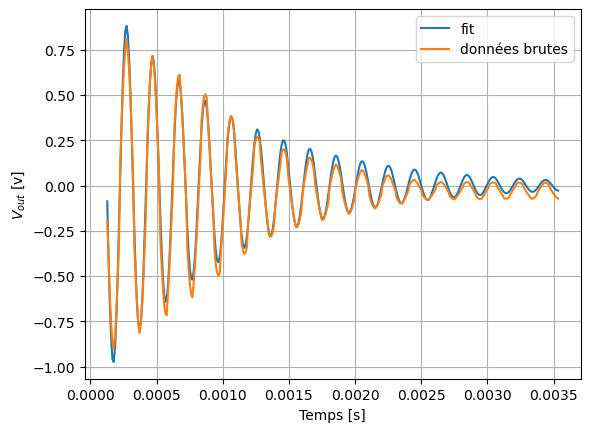

In [212]:
#plt.plot(time_cropped, model(time_cropped, *p0))
plt.plot(time_cropped, model(time_cropped, *popt), label ='fit')
plt.plot(time_cropped, Vin_cropped, label = 'données brutes')
plt.legend()
plt.xlabel("Temps [s]")
plt.ylabel("$V_{out}$ [v]")
plt.grid()
plt.show()

In [213]:
print(f"{alpha} +/- {u_alpha}")

-1054.6067100928115 +/- 17.149158190733843


In [214]:
Q = -1/(np.sqrt(L*C)*2*alpha)
print(Q)

14.992686988925382


Avec find peaks plutot

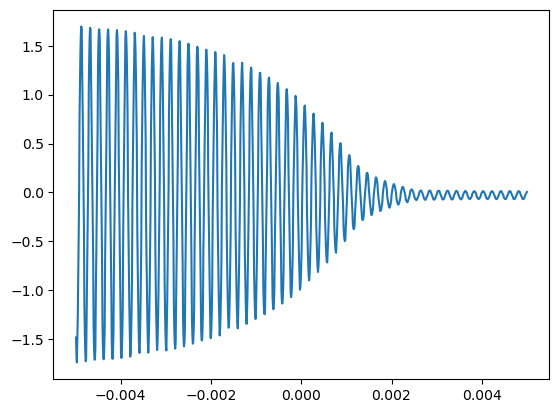

In [ ]:
plt.plot(time, Vin)


[ 10  30  50  70  90 111 132 152 172 192 213 233 253 273 293 314 334]


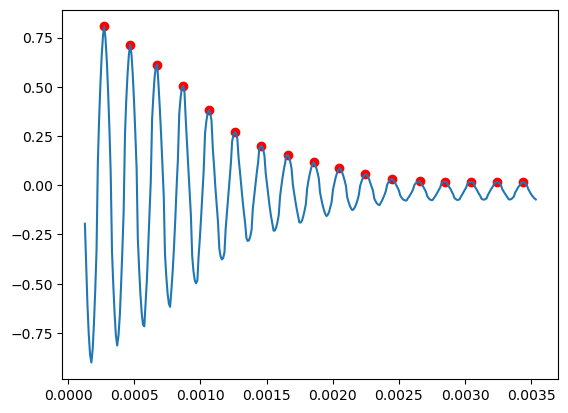

In [ ]:
from scipy.signal import find_peaks

peaks = find_peaks(Vin_cropped, height=None)
plt.plot(time_cropped, Vin_cropped)
print(peaks[0])

x = time_cropped[peaks[0]]
y = Vin_cropped[peaks[0]]
plt.scatter(x, y, color ='r')


In [217]:
def model_bis(t,alpha,A):
    return A*np.exp(alpha*t)

popt, pcov = curve_fit(model_bis, x,y, p0 = [-800,1])
alpha_bis,A = popt
print(alpha_bis)

Q = -1/(np.sqrt(L*C)*2*alpha_bis)
print(Q)


-1167.953622572827
13.53768505466148


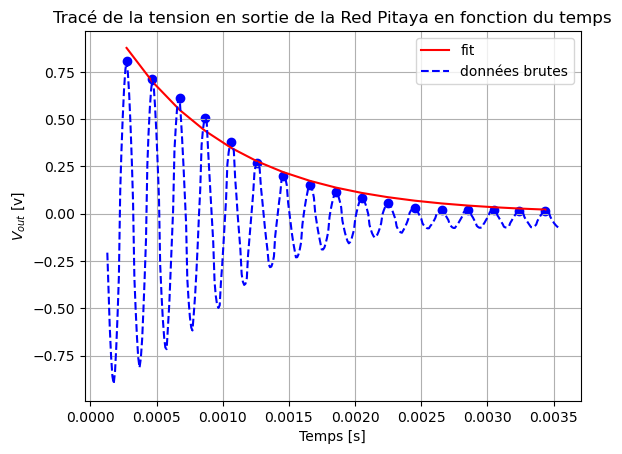

In [223]:
#plt.plot(time_cropped, model(time_cropped, *p0))
plt.title('Tracé de la tension en sortie de la Red Pitaya en fonction du temps')
plt.scatter(x, y, color ='b')
plt.plot(x,model_bis(x,*popt), color ='r', label ='fit')
plt.plot(time_cropped, Vin_cropped, color ='b', linestyle ='--', label ='données brutes')
plt.legend()
plt.xlabel("Temps [s]")
plt.ylabel("$V_{out}$ [v]")
plt.grid()
plt.show()


In [228]:
R = 218*1E3
R_p = 67*1E3

Q_th = R*R_p/(R+R_p)*C*1/(np.sqrt(L*C))
print(Q_th)

16.206395615585734
